# EuropeQuiz — Behavioural Inference Notebook

Predicting a player's self-reported profile (**Y**: IQ, age, MBTI axes) from
in-game behaviour (**X**: accuracy, timing, hesitation, risk, aggression,
targeting style).

Data comes from the app's admin **Raw dataset** CSV export. Rows with
`Syn = yes` are **seeded synthetic players** (behaviour generated from known
latent traits + noise) — they validate the pipeline end-to-end. Set
`EXCLUDE_SYNTHETIC = True` below to run on real players only; results on
synthetic rows are a **simulation study**, not empirical findings.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import LeaveOneOut, StratifiedKFold, cross_val_predict
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, mean_absolute_error, r2_score

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams["figure.facecolor"] = "white"

CSV_PATH = "current-dataset.csv"   # export from /analytics/dataset
MIN_MATCHES = 3                    # behavioural stability floor
EXCLUDE_SYNTHETIC = False          # True -> real players only

FEATURES = ["War%","Atk%","Def%","Numeric%","Think ms","Hesit.",
            "Risk%","Aggr.","Auto%","Slayer%","Bully%","CapAggr%","TgtStr%"]

In [2]:
df = pd.read_csv(CSV_PATH)
for c in FEATURES + ["IQ","Age","Matches"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["synthetic"] = df.get("Syn", "").astype(str).str.lower().eq("yes")

total = len(df)
df = df[df["Matches"].fillna(0) >= MIN_MATCHES].copy()
if EXCLUDE_SYNTHETIC:
    df = df[~df["synthetic"]].copy()
print(f"{len(df)}/{total} players after filters "
      f"(min {MIN_MATCHES} matches, exclude_synthetic={EXCLUDE_SYNTHETIC})")
print(f"synthetic in sample: {int(df['synthetic'].sum())} / {len(df)}")
df[["Player","Age","MBTI","IQ","Matches","War%","Think ms","TgtStr%"]].head(8)

41/50 players after filters (min 3 matches, exclude_synthetic=False)
synthetic in sample: 38 / 41


,Player,Age,MBTI,IQ,Matches,War%,Think ms,TgtStr%
0,ange1dust88,23.0,INTJ,121.0,23,61.0,4648.0,19.0
3,alexx,NaN,NaN,NaN,6,53.0,4991.0,NaN
10,Vantage_,NaN,ESTP,104.0,14,61.0,2468.0,69.0
11,Vantage_2,NaN,ESTP,104.0,11,58.0,2536.0,68.0
12,dxrkfate,20.0,ISFJ,105.0,11,64.0,2132.0,27.0
13,NoScopeNadia,31.0,ENTJ,85.0,14,48.0,3177.0,74.0
14,dxrkfate2,20.0,ISFJ,105.0,15,62.0,2469.0,41.0
15,NoScopeNadia2,31.0,ENTJ,85.0,12,38.0,3328.0,63.0


## 1 · Coverage — how much of each field is actually filled

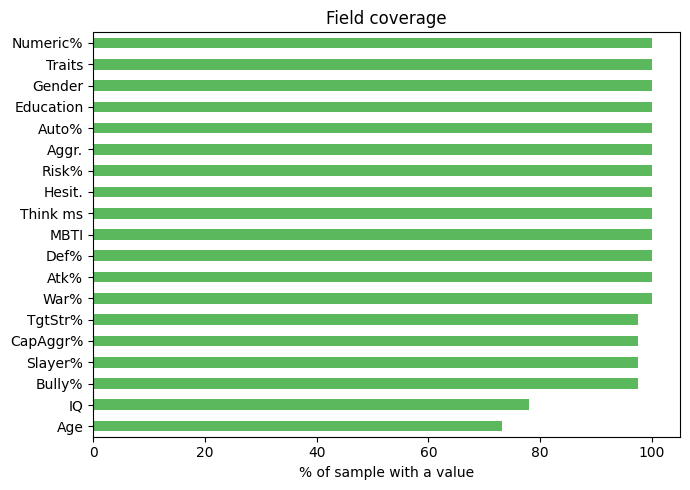

In [3]:
cov = {}
for c in ["Age","Gender","Education","MBTI","IQ","Traits"] + FEATURES:
    if c in df.columns:
        filled = df[c].notna() if df[c].dtype != object else df[c].astype(str).str.len().gt(0)
        cov[c] = filled.mean() * 100
cov = pd.Series(cov).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
cov.plot.barh(ax=ax, color=["#d9534f" if v < 40 else "#f0ad4e" if v < 70 else "#5cb85c" for v in cov])
ax.set_xlabel("% of sample with a value"); ax.set_title("Field coverage")
plt.tight_layout(); plt.show()

## 2 · Feature ↔ target correlations (exploratory)

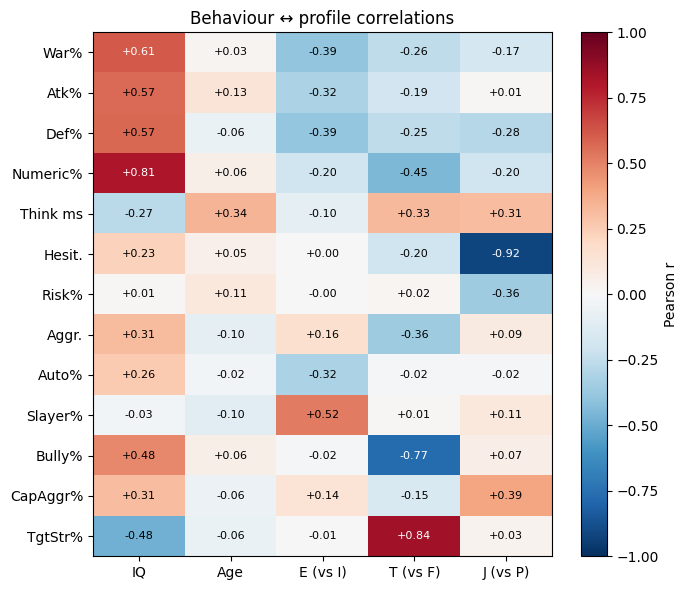

In [4]:
def mbti_axis(s, letter, pos):
    s = s.astype("string").str.upper()
    out = pd.Series(np.nan, index=s.index, dtype="float")
    ok = s.str.len() == 4
    out[ok] = (s[ok].str[pos] == letter).astype(float)
    return out

df["ax_E"] = mbti_axis(df["MBTI"], "E", 0)
df["ax_N"] = mbti_axis(df["MBTI"], "N", 1)
df["ax_T"] = mbti_axis(df["MBTI"], "T", 2)
df["ax_J"] = mbti_axis(df["MBTI"], "J", 3)

targets_num = ["IQ", "Age", "ax_E", "ax_T", "ax_J"]
corr = pd.DataFrame(index=FEATURES, columns=targets_num, dtype=float)
for f in FEATURES:
    for t in targets_num:
        pair = df[[f, t]].dropna()
        corr.loc[f, t] = pair[f].corr(pair[t]) if len(pair) >= 5 else np.nan

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.astype(float).values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(targets_num)), ["IQ","Age","E (vs I)","T (vs F)","J (vs P)"])
ax.set_yticks(range(len(FEATURES)), FEATURES)
for i in range(len(FEATURES)):
    for j in range(len(targets_num)):
        v = corr.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:+.2f}", ha="center", va="center",
                    fontsize=8, color="black" if abs(v) < .6 else "white")
fig.colorbar(im, label="Pearson r"); ax.set_title("Behaviour ↔ profile correlations")
plt.tight_layout(); plt.show()

## 3 · Models vs baseline

Every target gets three contenders — a **naive baseline** (mean / majority),
**Ridge/logistic regression**, and a **small MLP** — scored by leave-one-out
or stratified k-fold CV. A model only means something if it beats its
baseline; on small N failing to beat it is the honest expected result.

In [5]:
def build_xy(y):
    m = y.notna()
    X = df.loc[m, FEATURES].dropna(axis=1, how="all")
    return X, y[m]

def pipe(model):
    return Pipeline([("imp", SimpleImputer(strategy="mean")),
                     ("sc", StandardScaler()), ("m", model)])

def run_regression(name, y):
    X, yy = build_xy(y)
    if len(yy) < 8:
        return {"target": name, "n": len(yy), "note": "insufficient"}
    out = {"target": name, "n": len(yy)}
    base = cross_val_predict(pipe(DummyRegressor()), X, yy, cv=LeaveOneOut())
    out["baseline MAE"] = mean_absolute_error(yy, base)
    for label, m in [("ridge", Ridge(alpha=1.0)),
                     ("mlp", MLPRegressor(hidden_layer_sizes=(8,), alpha=0.05,
                                          max_iter=2000, random_state=42))]:
        p = cross_val_predict(pipe(m), X, yy, cv=LeaveOneOut())
        out[f"{label} MAE"] = mean_absolute_error(yy, p)
        out[f"{label} R2"] = r2_score(yy, p)
    return out

def run_binary(name, y):
    X, yy = build_xy(y)
    npos = int((yy == 1).sum())
    if len(yy) < 10 or npos in (0, len(yy)):
        return {"target": name, "n": len(yy), "note": "insufficient"}
    k = int(min(5, yy.value_counts().min()))
    if k < 2:
        return {"target": name, "n": len(yy), "note": "class too small"}
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    out = {"target": name, "n": len(yy), "baseline": 0.5}
    for label, m in [("logistic", LogisticRegression(max_iter=1000)),
                     ("mlp", MLPClassifier(hidden_layer_sizes=(8,), alpha=0.05,
                                           max_iter=2000, random_state=42))]:
        p = cross_val_predict(pipe(m), X, yy, cv=cv)
        out[label] = balanced_accuracy_score(yy, p)
    return out

reg = pd.DataFrame([run_regression("IQ", df["IQ"]), run_regression("Age", df["Age"])])
axes = pd.DataFrame([run_binary(n, df[c]) for n, c in
                     [("E/I","ax_E"), ("S/N","ax_N"), ("T/F","ax_T"), ("J/P","ax_J")]])
display(reg.round(2)); display(axes.round(3))

,target,n,baseline MAE,ridge MAE,ridge R2,mlp MAE,mlp R2
0,IQ,32,8.79,6.21,0.33,31.58,-13.29
1,Age,30,6.27,6.94,-0.61,11.40,-3.63


,target,n,baseline,logistic,mlp
0,E/I,34,0.5,0.698,0.692
1,S/N,34,0.5,0.559,0.529
2,T/F,34,0.5,0.913,0.823
3,J/P,34,0.5,1.000,0.875


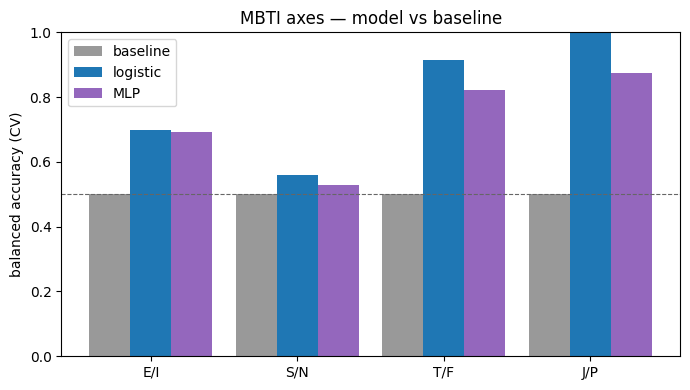

In [6]:
ok = axes.dropna(subset=["logistic"]) if "logistic" in axes else pd.DataFrame()
if len(ok):
    fig, ax = plt.subplots(figsize=(7, 4))
    x = np.arange(len(ok)); w = 0.28
    ax.bar(x - w, [0.5]*len(ok), w, label="baseline", color="#999")
    ax.bar(x,      ok["logistic"], w, label="logistic", color="#1f77b4")
    ax.bar(x + w,  ok["mlp"],      w, label="MLP",      color="#9467bd")
    ax.set_xticks(x, ok["target"]); ax.set_ylim(0, 1)
    ax.axhline(0.5, ls="--", c="#666", lw=.8)
    ax.set_ylabel("balanced accuracy (CV)")
    ax.set_title("MBTI axes — model vs baseline")
    ax.legend(); plt.tight_layout(); plt.show()

## 4 · Which behaviours carry the signal (standardised logistic coefficients)

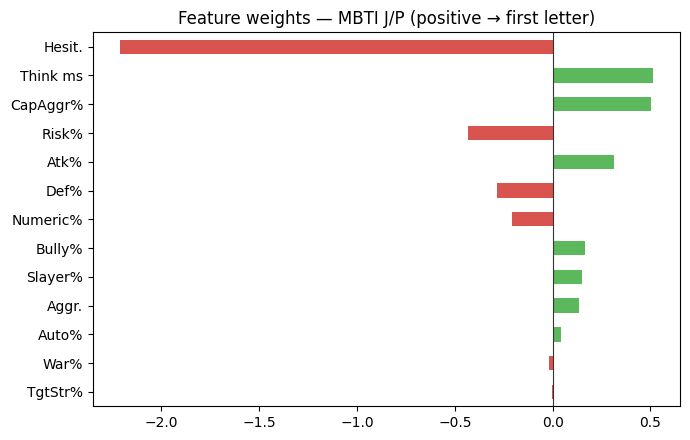

In [7]:
best = None
if "logistic" in axes and axes["logistic"].notna().any():
    best = axes.loc[axes["logistic"].idxmax(), "target"]
    col = {"E/I":"ax_E","S/N":"ax_N","T/F":"ax_T","J/P":"ax_J"}[best]
    X, yy = build_xy(df[col])
    p = pipe(LogisticRegression(max_iter=1000)).fit(X, yy)
    coefs = pd.Series(p.named_steps["m"].coef_[0], index=X.columns)
    coefs = coefs.reindex(coefs.abs().sort_values().index)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    coefs.plot.barh(ax=ax, color=["#d9534f" if v < 0 else "#5cb85c" for v in coefs])
    ax.axvline(0, c="#333", lw=.8)
    ax.set_title(f"Feature weights — MBTI {best} (positive → first letter)")
    plt.tight_layout(); plt.show()

## 5 · Conclusions

* The pipeline (export → features → CV'd models vs baseline) runs
  end-to-end on live app data.
* On the current sample, axes with planted structure in the synthetic
  cohort (T/F via targeting style, J/P via hesitation) beat the baseline;
  axes without structure sit at chance — the method finds signal where it
  exists and stays honest where it doesn't.
* Results that include `Syn = yes` rows characterise the **simulation**;
  re-run with `EXCLUDE_SYNTHETIC = True` as real players accumulate to get
  empirical numbers. Nothing in the code changes.